# Text Summarization in Python
## Motivation:
### The length of textual data is increasing and people have less time. Often the newspaper articles run into a long text of, say 1000 -1200 words. As wearable devices leap to prominence (Google Glass, Apple Watch, to name a few), content must adapt to the limited screen space available on these devices. The task of generating intelligent and accurate summaries for long pieces of text has become a popular research as well as industry problem.

## Approach:
### Extractive text summarization is all about finding the more important sentences from a document as a summary of that document. Our approach is using the TextRank algorithm to find these 'important' sentences.

## Implementation
## 1. Importing important libraries

In [ ]:
import numpy as np
import PyPDF2
import docx2txt
import sys
import matplotlib.pyplot as plt
%matplotlib inline 
import networkx as nx
from nltk.tokenize.punkt import PunktSentenceTokenizer
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer

## 2. Function to read the document from user
### Supported formats: .txt, .pdf

### Input: Takes the name of the file as input.

### Output: Returns a string output containing the contents of the file.

In [ ]:
# we are going to show an example of how the method is working
# first let's take the document as an input
def readDoc():
    name = input('Please input a file name: ') 
    print('You have asked for the document {}'.format(name))

    # now read the type of document
    if name.lower().endswith('.txt'):
        choice = 1
    elif name.lower().endswith('.pdf'):
        choice = 2
    else:
        choice = 3
        # print(name)
    print(choice)
    # Case 1: if it is a .txt file
        
    if choice == 1:
        f = open(name, 'r')
        document = f.read()
        f.close()
            
    # Case 2: if it is a .pdf file
    elif choice == 2:
        pdfFileObj = open(name, 'rb')
        pdfReader = PyPDF2.PdfFileReader(pdfFileObj)
        pageObj = pdfReader.getPage(0)
        document = pageObj.extractText()
        pdfFileObj.close()
    
    # Case 3: none of the format
    else:
        print('Failed to load a valid file')
        print('Returning an empty string')
        document = ''
    
    print(type(document))
    return document

## 3. Function to tokenize the document
### Input: String of text document

### Output: A list containing sentences as its elements

In [ ]:
# the function used for tokenizing the sentences
# tokenization of a sentence: '''provided in cell() above'''

def tokenize(document):
    # We are tokenizing using the PunktSentenceTokenizer
    # we call an instance of this class as sentence_tokenizer
    doc_tokenizer = PunktSentenceTokenizer()
    
    # tokenize() method: takes our document as input and returns a list of all the sentences in the document
    
    # sentences is a list containing each sentence of the document as an element
    sentences_list = doc_tokenizer.tokenize(document)
    return sentences_list

## 4. Read the document

In [ ]:
# reading a file and 
# printing the size of the file
document = readDoc()
print('The length of the file is:', end=' ')
print(len(document))

Please input a file name: F:\adventure of lone wolf.txt
You have asked for the document F:\adventure of lone wolf.txt
1
<class 'str'>
The length of the file is: 25266


## 5. Generate a list of sentences in the document

In [ ]:
# we want to tokenize the document for further processing
# tokenizing the sentence means that we are creating a list of all the sentences of the document.
# Need of tokenizing the document: Initially the document is in just a string format.
# if we want to process the document, we need to store it in a data structure.
# Tokenization of document into words is also possible, but we will go with the tokenizing with the sentences
# Since we want to choose the most relevant sentences, we need to generate tokens of sentences only
sentences_list = tokenize(document)

# let us print the size of memory used by the list sentences
print('The size of the list in Bytes is: {}'.format(sys.getsizeof(sentences_list)))

# the size of one of the element of the list
print('The size of the item 0 in Bytes is: {}'.format(sys.getsizeof(sentences_list[0])))

The size of the list in Bytes is: 3208
The size of the item 0 in Bytes is: 224


In [ ]:
# let us see the data type of sentences_list
# It will be list
print(type(sentences_list))

<class 'list'>


In [ ]:
# let us analyse the elements of the sentences
# len() method applies on the list and provides the number of elements in the list
print('The size of the list "sentences" is: {}'.format(len(sentences_list)))

The size of the list "sentences" is: 344


In [ ]:
# print the elements of the list
# If the input document is long, which on realistically will be wrong, we would not like to print the entire document
for i in sentences_list:
    print(i)

"THE ADVENTURES OF LONE WOLF SCIENTIFIC"

After a long night of bickering over how to arrange the
office furniture, the new high-tech startup company is
visited by a neighbor.
Dawn's dauntless talons were making their first
tentative poke through the cracked windows of the former
fraternity house where the two entrepreneurs had argued the
night away, when there came a pounding on the front door.
It was loud and not at all hospitable sounding.
"It is no doubt the furniture police come to arrest you
for your appallingly bad taste in the arrangement of office
furniture," the computer builder grumped as he stalked to
the door.
"It's not my fault that no matter where we push your
precious research and development couch it causes the floor
to buckle and sag."
The programmer cowered on top the file
cabinet, peering cautiously over a pillow he grasped in
front of him like a warrior's shield.
He clenched in one
hand, as tightly as if it were a sacred parchment, a
calendar topped by a photo of a

## 6. Generate term-document matrix (TD matrix) of the data

In [ ]:
# Convert a collection of text documents to a matrix of token counts
# fit_transform method of CountVectorizer() class 
# Learn the vocabulary dictionary and return term-document matrix. 
# I/p: An iterable which yields either str, unicode or file objects.
# O/p: The term-document matrix named cv_matrix
cv = CountVectorizer()
cv_matrix = cv.fit_transform(sentences_list)

### So what does CountVectorizer.fit_transform() do?

In [ ]:
# a demo of what CountVectorizer().fit_transform(text) does
cv_demo = CountVectorizer() # a demo object of class CountVectorizer

# I have repeated the words to make a non-ambiguous array of the document text matrix 

text_demo = ["Ashish is good, you are bad", "I am not bad"] 
res_demo = cv_demo.fit_transform(text_demo)
print('Result demo array is {}'.format(res_demo.toarray()))

# Result is 2-d matrix containing document text matrix
# Notice that in the second row, there is 2.
# also, bad is repeated twice in that sentence.
# so we can infer that 2 is corresponding to the word 'bad'
print('Feature list: {}'.format(cv_demo.get_feature_names()))

Result demo array is [[0 1 1 1 1 1 0 1]
 [1 0 0 1 0 0 1 0]]
Feature list: ['am', 'are', 'ashish', 'bad', 'good', 'is', 'not', 'you']


c:\users\tanuj\appdata\local\programs\python\python37\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
# printing the cv_matrix type
# and how it is being stored in memory?
# it is stored in the compressed row format
# compressed row format: 
print('The data type of bow matrix {}'.format(type(cv_matrix)))
print('Shape of the matrix {}'.format(cv_matrix.get_shape))
print('Size of the matrix is: {}'.format(sys.getsizeof(cv_matrix)))
print(cv.get_feature_names())
print(cv_matrix.toarray())

The data type of bow matrix <class 'scipy.sparse.csr.csr_matrix'>
Shape of the matrix <bound method spmatrix.get_shape of <344x1246 sparse matrix of type '<class 'numpy.int64'>'
	with 3767 stored elements in Compressed Sparse Row format>>
Size of the matrix is: 56
['000', '16', '18th', '20', '45', '47', '587', '700', 'ability', 'able', 'about', 'above', 'accused', 'across', 'act', 'acting', 'adding', 'admiration', 'admit', 'ads', 'advantage', 'adventures', 'afraid', 'afro', 'after', 'again', 'ago', 'agreed', 'air', 'aisle', 'alarms', 'all', 'alley', 'alligator', 'almost', 'along', 'alphabetical', 'already', 'also', 'altered', 'although', 'am', 'amazed', 'amazement', 'american', 'among', 'amount', 'an', 'and', 'andrew', 'angles', 'annoyance', 'another', 'any', 'anything', 'appallingly', 'appear', 'apples', 'appropriate', 'approval', 'approvingly', 'apt', 'archibald', 'are', 'argued', 'arguing', 'arguments', 'arising', 'arm', 'arms', 'around', 'arrange', 'arranged', 'arrangement', 'arres

## 7. Normalization of matrix

In [ ]:
# Tnormalized: document-term matrix normalized (value 0-1) according to the TF-IDF
# TF(Term Frequency): the no. of times a term(a word here) appears in the current document(single sentence here)
# IDF(Inverse Document Frequency): the no. of times a term(a word here) appears in the entire corpus
# Corpus: set of all sentences

normal_matrix = TfidfTransformer().fit_transform(cv_matrix)
print(normal_matrix.toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
print(normal_matrix.T.toarray)
res_graph = normal_matrix * normal_matrix.T
# plt.spy(res_graph)
res_graph

<bound method _cs_matrix.toarray of <1246x344 sparse matrix of type '<class 'numpy.float64'>'
	with 3767 stored elements in Compressed Sparse Column format>>


<344x344 sparse matrix of type '<class 'numpy.float64'>'
	with 46128 stored elements in Compressed Sparse Row format>

Number of edges 23236
Number of vertices 344


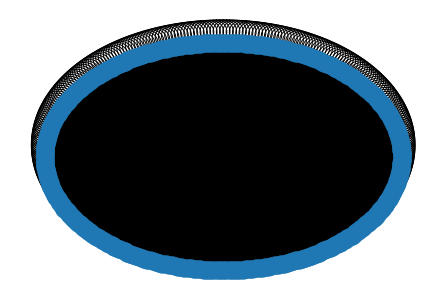

The memory used by the graph in Bytes is: 56


In [ ]:
# drawing a graph to proceed for the textrank algorithm
# nx_graph is a graph developed using the networkx library
# each node represents a sentence
# an edge represents that they have words in common
# the edge weight is the number of words that are common in both of the sentences(nodes)
# nx.draw() method is used to draw the graph created

nx_graph = nx.from_scipy_sparse_matrix(res_graph)
nx.draw_circular(nx_graph)
print('Number of edges {}'.format(nx_graph.number_of_edges()))
print('Number of vertices {}'.format(nx_graph.number_of_nodes()))
plt.show()
print('The memory used by the graph in Bytes is: {}'.format(sys.getsizeof(nx_graph)))

In [ ]:
#  note that the graph above is dense and therefor it resembles a circle
# if a shorter document is taken, a beautiful circular graph can be seen 

## 8. Getting the rank of every sentence using textrank

In [ ]:
# ranks is a dictionary with key=node(sentences) and value=textrank (the rank of each of the sentences)
ranks = nx.pagerank(nx_graph)

# analyse the data type of ranks
print(type(ranks))
print('The size used by the dictionary in Bytes is: {}'.format(sys.getsizeof(ranks)))

# print the dictionary
for i in ranks:
    print(i, ranks[i])

<class 'dict'>
The size used by the dictionary in Bytes is: 18528
0 0.004463869342260944
1 0.003508346545965441
2 0.002996644838039759
3 0.005320408790293013
4 0.004289013637932919
5 0.0036345601655935512
6 0.0030803063370326237
7 0.001891560399785332
8 0.0038700401319051356
9 0.002736150219297446
10 0.002806363227445696
11 0.00269298615203242
12 0.003459699435206505
13 0.003934672664004329
14 0.002332581644065347
15 0.0024680669570454248
16 0.0027385580743154838
17 0.004109481544314932
18 0.003991061610408249
19 0.002791966360705942
20 0.004293171258244256
21 0.0033481453560084713
22 0.0015575561739426184
23 0.0019850879193268724
24 0.0030773123048300484
25 0.0022284949318434814
26 0.0027523770213087498
27 0.0019888962779633108
28 0.005221402751935356
29 0.005198376978222925
30 0.0027385580743154838
31 0.002746832163971325
32 0.005214870928995172
33 0.001284045782505121
34 0.0021462031717288245
35 0.004685679436402076
36 0.0036232347696524047
37 0.0019231726385868526
38 0.002582165850

## 9. Finding important sentences and generating summary

In [ ]:
# enumerate method: returns an enumerate object
# Use of list Comprehensions
# O/p: sentence_array is the sorted(descending order w.r.t. score value) 2-d array of ranks[sentence] and sentence 
# For example, if there are two sentences: S1 (with a score of S1 = s1) and S2 with score s2, with s2>s1
# then sentence_array is [[s2, S2], [s1, S1]]
sentence_array = sorted(((ranks[i], s) for i, s in enumerate(sentences_list)), reverse=True)
sentence_array = np.asarray(sentence_array)

In [ ]:
# as sentence_array is in descending order wrt score value
# fmax is the largest score value(the score of first element)
# fmin is the smallest score value(the score of last element)

rank_max = float(sentence_array[0][0])
rank_min = float(sentence_array[len(sentence_array) - 1][0])

In [ ]:
# print the largest and smallest value of scores of the sentence
print(rank_max)
print(rank_min)

0.0054961483982580404
0.0011818578560489378


In [ ]:
# Normalization of the scores
# so that it comes out in the range 0-1
# fmax becomes 1
# fmin becomes 0
# store the normalized values in the list temp_array

temp_array = []

# if all sentences have equal ranks, means they are all the same
# taking any sentence will give the summary, say the first sentence
flag = 0
if rank_max - rank_min == 0:
    temp_array.append(0)
    flag = 1

# If the sentence has different ranks
if flag != 1:
    for i in range(0, len(sentence_array)):
        temp_array.append((float(sentence_array[i][0]) - rank_min) / (rank_max - rank_min))

print(len(temp_array))

344


In [ ]:
# Calculation of threshold:
# We take the mean value of normalized scores
# any sentence with the normalized score 0.2 more than the mean value is considered to be 
threshold = (sum(temp_array) / len(temp_array)) + 0.2

In [ ]:
# Separate out the sentences that satiasfy the criteria of having a score above the threshold
sentence_list = []
if len(temp_array) > 1:
    for i in range(0, len(temp_array)):
        if temp_array[i] > threshold:
                sentence_list.append(sentence_array[i][1])
else:
    sentence_list.append(sentence_array[0][1])

In [ ]:
model = sentence_list

## 10. Writing the summary to a new file

In [ ]:
# print(sentence_list)
summary = " ".join(str(x) for x in sentence_list)
print(summary)
# save the data in another file, names sum.txt
f = open('final3.txt', 'a+')
#print(type(f))
f.write('\n')
f.write(summary)
f.close

The computer builder grunted in indignation at the
thought of someone charging him for the privilege of
restoring the artwork on his van, an honor he considered not
uncomparable to being asked to touch up the  ceiling of the
Sistine Chapel. The
pale green lines and the holes along the sides of the
printouts are so realistic that even I would be unable to
distinguish it from computer paper heaped in the corner of
my office. "It is no doubt the furniture police come to arrest you
for your appallingly bad taste in the arrangement of office
furniture," the computer builder grumped as he stalked to
the door. The
computer builder pointed to the purple slot machine painted
in the bottom corner of the sign. Here we are, less than a day
later, with a company name, a company motto (not to mention
a company warranty policy and liability disclaimer), and a
classy sign which, although it doesn't have a nude woman on
it, will still look fetching when hung from the broken
balcony railing on the front

<function TextIOWrapper.close()>

In [ ]:
for lines in sentence_list:
    print(lines)

The computer builder grunted in indignation at the
thought of someone charging him for the privilege of
restoring the artwork on his van, an honor he considered not
uncomparable to being asked to touch up the  ceiling of the
Sistine Chapel.
The
pale green lines and the holes along the sides of the
printouts are so realistic that even I would be unable to
distinguish it from computer paper heaped in the corner of
my office.
"It is no doubt the furniture police come to arrest you
for your appallingly bad taste in the arrangement of office
furniture," the computer builder grumped as he stalked to
the door.
The
computer builder pointed to the purple slot machine painted
in the bottom corner of the sign.
Here we are, less than a day
later, with a company name, a company motto (not to mention
a company warranty policy and liability disclaimer), and a
classy sign which, although it doesn't have a nude woman on
it, will still look fetching when hung from the broken
balcony railing on the front